# classification using pose

In [2]:
import time as t
import os
import numpy as np
from ultralytics import YOLO
from glob import glob
import cv2
import json
import yaml
import tqdm as tqdm
from pathlib import Path
import matplotlib.pyplot as plt 
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import tqdm 


from yolo_cam.eigen_cam import EigenCAM
from yolo_cam.utils.image import show_cam_on_image, scale_cam_image

# config

In [3]:
dataset_dir = "../datasets/"
dataset_path = Path(dataset_dir)
posecls_dataset_dir = dataset_path / "AllSpecies-posecls"
groups = ["Coleoptera", "Hymenoptera", "Lepidoptera"]
config_file = "yolo26n-pose.pt"

## preparation

In [4]:
all_test_images = [img for img in posecls_dataset_dir.rglob("**/*.png") if "test" in img.parts] + [img for img in posecls_dataset_dir.rglob("**/*.jpg") if "test" in img.parts]
print(f"Total test images: {len(all_test_images)}")

def get_cls_from_label_file(label_file):
    # get a text file yolo format and return the class of the label
    with open(label_file, 'r') as f:
        lines = f.readlines()
    data = [line.strip().split() for line in lines]
    return int(data[0][0]) if data else None

label_dict = {all_test_images[i]: groups[get_cls_from_label_file(str(all_test_images[i]).replace("images", "labels").replace(".jpg", ".txt").replace(".png", ".txt"))] for i in range(len(all_test_images))}
# reverse dict with a list of images for each class
class_dict = {i: [] for i in groups}
for img, cls in label_dict.items():
    class_dict[cls].append(img)

Total test images: 145


 # yolo loading

In [5]:
model = YOLO(config_file)

# training

In [8]:
results = model.train(data=posecls_dataset_dir / "yolo-config.yaml", epochs=10, imgsz=640)

New https://pypi.org/project/ultralytics/8.4.60 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.54 🚀 Python-3.12.3 torch-2.11.0+cu130 CUDA:0 (NVIDIA GeForce RTX 4060, 7805MiB)


engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../datasets/AllSpecies-posecls/yolo-config.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n-pose.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-3, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0, pretrained=True, 

# evaluation

In [9]:
# model loading if no training
model = YOLO("./runs/pose/train/weights/best.pt")

y_true = []
y_pred = []

misclassified_images = []

for img in tqdm.tqdm(all_test_images):
    true_label = label_dict[img]  # Assuming the folder name is the class label
    y_true.append(true_label)
    
    result = model(str(img), conf=0.25)[0]

    if len(result.boxes.cls) > 0:
        pred_label = int(result.boxes.cls[0].item())  # Get the predicted class index
        y_pred.append(groups[pred_label])  # Map index to class name
    else:
        y_pred.append("No Detection")  # Handle case where no detection is made
    
    if true_label != y_pred[-1]:
        misclassified_images.append((img, true_label, y_pred[-1]))
    
    


  0%|          | 0/145 [00:00<?, ?it/s]


image 1/1 /home/tombellivier/Documents/CV/CV-for-GRIT/models/classifier/../datasets/AllSpecies-posecls/images/test/IMG_0313_specimen_3_TREOBT_NEON.BET.D20.002080.png: 640x544 2 Coleopteras, 45.2ms
Speed: 0.9ms preprocess, 45.2ms inference, 0.2ms postprocess per image at shape (1, 3, 640, 544)


  1%|          | 1/145 [00:00<00:19,  7.23it/s]


image 1/1 /home/tombellivier/Documents/CV/CV-for-GRIT/models/classifier/../datasets/AllSpecies-posecls/images/test/IMG_0291_specimen_3_MECKON_NEON.BET.D20.001719.png: 640x352 1 Coleoptera, 44.4ms
Speed: 0.6ms preprocess, 44.4ms inference, 0.2ms postprocess per image at shape (1, 3, 640, 352)

image 1/1 /home/tombellivier/Documents/CV/CV-for-GRIT/models/classifier/../datasets/AllSpecies-posecls/images/test/IMG_0193_specimen_4_MECRUF_NEON.BET.D20.000047.png: 640x320 1 Coleoptera, 45.0ms
Speed: 0.5ms preprocess, 45.0ms inference, 0.2ms postprocess per image at shape (1, 3, 640, 320)


  2%|▏         | 3/145 [00:00<00:10, 13.57it/s]

...

 95%|█████████▌| 138/145 [00:03<00:00, 31.65it/s]


image 1/1 /home/tombellivier/Documents/CV/CV-for-GRIT/models/classifier/../datasets/AllSpecies-posecls/images/test/F.17877.jpg: 448x640 1 Lepidoptera, 4.0ms
Speed: 1.3ms preprocess, 4.0ms inference, 0.2ms postprocess per image at shape (1, 3, 448, 640)

image 1/1 /home/tombellivier/Documents/CV/CV-for-GRIT/models/classifier/../datasets/AllSpecies-posecls/images/test/EA8.1NZ.jpg: 448x640 1 Lepidoptera, 3.8ms
Speed: 0.8ms preprocess, 3.8ms inference, 0.2ms postprocess per image at shape (1, 3, 448, 640)

image 1/1 /home/tombellivier/Documents/CV/CV-for-GRIT/models/classifier/../datasets/AllSpecies-posecls/images/test/EA4.0OC.jpg: 448x640 1 Lepidoptera, 3.8ms
Speed: 0.8ms preprocess, 3.8ms inference, 0.2ms postprocess per image at shape (1, 3, 448, 640)

image 1/1 /home/tombellivier/Documents/CV/CV-for-GRIT/models/classifier/../datasets/AllSpecies-posecls/images/test/Dasypoda_pyrotrichia_F_001.jpg: 640x544 1 Hymenoptera, 4.5ms
Speed: 1.0ms preprocess, 4.5ms inference, 0.2ms postprocess p

 98%|█████████▊| 142/145 [00:03<00:00, 33.66it/s]


image 1/1 /home/tombellivier/Documents/CV/CV-for-GRIT/models/classifier/../datasets/AllSpecies-posecls/images/test/F.1015.jpg: 448x640 1 Lepidoptera, 4.3ms
Speed: 1.3ms preprocess, 4.3ms inference, 0.2ms postprocess per image at shape (1, 3, 448, 640)

image 1/1 /home/tombellivier/Documents/CV/CV-for-GRIT/models/classifier/../datasets/AllSpecies-posecls/images/test/EB1.050.jpg: 448x640 1 Lepidoptera, 3.9ms
Speed: 0.9ms preprocess, 3.9ms inference, 0.2ms postprocess per image at shape (1, 3, 448, 640)

image 1/1 /home/tombellivier/Documents/CV/CV-for-GRIT/models/classifier/../datasets/AllSpecies-posecls/images/test/F.12745.jpg: 448x640 1 Lepidoptera, 4.0ms
Speed: 1.4ms preprocess, 4.0ms inference, 0.2ms postprocess per image at shape (1, 3, 448, 640)


100%|██████████| 145/145 [00:03<00:00, 39.86it/s]


In [10]:
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot().figure_.savefig('results/pose/confusion_matrix.png')
disp.plot()


0: 640x640 1 Hymenoptera, 254.2ms
Speed: 6.8ms preprocess, 254.2ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 640)


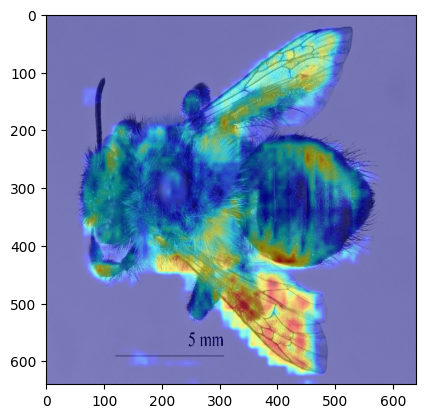

In [ ]:
model = YOLO("./runs/pose/train/weights/best.pt")
model = model.cpu()

target_layers = [model.model.model[16]]

img = cv2.imread('images/hymenoptera.jpg')
img = cv2.resize(img, (640, 640))
rgb_img = img.copy()
img = np.float32(img) / 255

cam = EigenCAM(model, target_layers, task='od')
grayscale_cam = cam(rgb_img)[0, :, :]
cam_image = show_cam_on_image(img, grayscale_cam, use_rgb=True)
plt.imshow(cam_image)
plt.savefig('results/pose/cam.png')
plt.show()

In [ ]:
print(model)

YOLO(
  (model): PoseModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
        (act): SiLU(inplace=True)
      )
      (2): C3k2(
        (cv1): Conv(
          (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1))
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(48, 64, kernel_size=(1, 1), stride=(1, 1))
          (act): SiLU(inplace=True)
        )
        (m): ModuleList(
          (0): Bottleneck(
            (cv1): Conv(
              (conv): Conv2d(16, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
              (act): SiLU(inplace=True)
            )
            (cv2): Conv(
              (conv): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
              (act): SiLU(inplace=True)
         